In [1]:
import os

os.environ['KAGGLE_USERNAME'] = "abishekarun05"
os.environ['KAGGLE_KEY'] = "KGAT_e245ee737d38219a541f77433449e8e2"

In [2]:
!kaggle datasets download -d ankit8467/dataset-for-dbscan

Dataset URL: https://www.kaggle.com/datasets/ankit8467/dataset-for-dbscan
License(s): unknown
100% 39.3k/39.3k [00:00<00:00, 55.5MB/s]



In [3]:
import zipfile
import os

# Path to your zip file
#zip_path = "/content/dataset-for-dbscan.zip"
extract_path = "extracted_files"

# Create folder if not exists
os.makedirs(extract_path, exist_ok=True)

# Extract all files
#with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    #zip_ref.extractall(extract_path)

print("✅ Files extracted to:", extract_path)

✅ Files extracted to: extracted_files


In [4]:
# ==========================================
# HIERARCHICAL CLUSTERING
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import dendrogram, linkage

import zipfile
import os

In [5]:
# ==========================================
# Step 4: Load Dataset
# ==========================================

data = pd.read_csv("/content/marketing_data.csv")

data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,84835.0,0,0,2014-06-16,0,189,...,6,1,0,0,0,0,0,1,0,Spain
1,1,1961,Graduation,Single,57091.0,0,0,2014-06-15,0,464,...,7,5,0,0,0,0,1,1,0,Canada
2,10476,1958,Graduation,Married,67267.0,0,1,2014-05-13,0,134,...,5,2,0,0,0,0,0,0,0,USA
3,1386,1967,Graduation,Together,32474.0,1,1,2014-05-11,0,10,...,2,7,0,0,0,0,0,0,0,Australia
4,5371,1989,Graduation,Single,21474.0,1,0,2014-04-08,0,6,...,2,7,1,0,0,0,0,1,0,Spain


In [6]:
# ==========================================
# Step 5: Dataset Information
# ==========================================

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4    Income              2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [7]:
# ==========================================
# Step 6: Dataset Shape
# ==========================================

print("Rows :", data.shape[0])
print("Columns :", data.shape[1])

Rows : 2240
Columns : 28


In [8]:
# ==========================================
# Step 7: Missing Values
# ==========================================

data.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [9]:
# ==========================================
# Step 8: Duplicate Values
# ==========================================

print("Duplicate Rows :", data.duplicated().sum())

Duplicate Rows : 0


In [10]:
# ==========================================
# Step 9: Statistical Summary
# ==========================================

data.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.149107,0.009375
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.356274,0.096391
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [16]:
# ==========================================
# Step 10: Feature Selection
# ==========================================

X = data[['ID','Year_Birth']]

X.head()

,ID,Year_Birth
0,1826,1970
1,1,1961
2,10476,1958
3,1386,1967
4,5371,1989


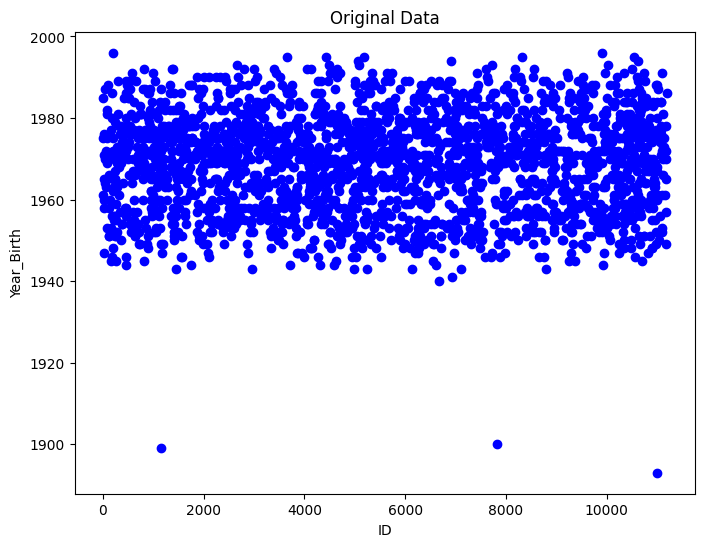

In [18]:
# ==========================================
# Step 11: Original Data Visualization
# ==========================================

plt.figure(figsize=(8,6))

plt.scatter(
    X['ID'],
    X['Year_Birth'],
    color='blue'
)

plt.title("Original Data")

plt.xlabel("ID")

plt.ylabel("Year_Birth")

plt.show()

In [19]:
# ==========================================
# Step 12: Feature Scaling
# ==========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

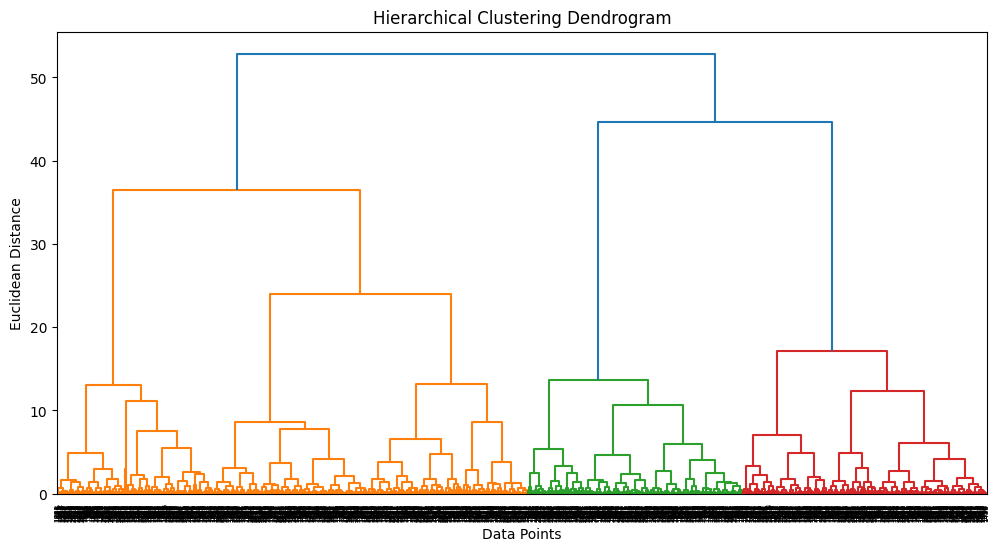

In [20]:
# ==========================================
# Step 13: Dendrogram
# ==========================================

linked = linkage(
    X_scaled,
    method='ward'
)

plt.figure(figsize=(12,6))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Data Points")

plt.ylabel("Euclidean Distance")

plt.show()

In [21]:
# ==========================================
# Step 14: Train Model
# ==========================================

hc = AgglomerativeClustering(
    n_clusters=3,
    metric='euclidean',
    linkage='ward'
)

clusters = hc.fit_predict(X_scaled)

In [22]:
# ==========================================
# Step 15: Add Cluster Column
# ==========================================

data["Cluster"] = clusters

data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Cluster
0,1826,1970,Graduation,Divorced,84835.0,0,0,2014-06-16,0,189,...,1,0,0,0,0,0,1,0,Spain,1
1,1,1961,Graduation,Single,57091.0,0,0,2014-06-15,0,464,...,5,0,0,0,0,1,1,0,Canada,0
2,10476,1958,Graduation,Married,67267.0,0,1,2014-05-13,0,134,...,2,0,0,0,0,0,0,0,USA,0
3,1386,1967,Graduation,Together,32474.0,1,1,2014-05-11,0,10,...,7,0,0,0,0,0,0,0,Australia,0
4,5371,1989,Graduation,Single,21474.0,1,0,2014-04-08,0,6,...,7,1,0,0,0,0,1,0,Spain,1


In [23]:
# ==========================================
# Step 16: Cluster Count
# ==========================================

print(data["Cluster"].value_counts())

Cluster
0    1135
1     588
2     517
Name: count, dtype: int64


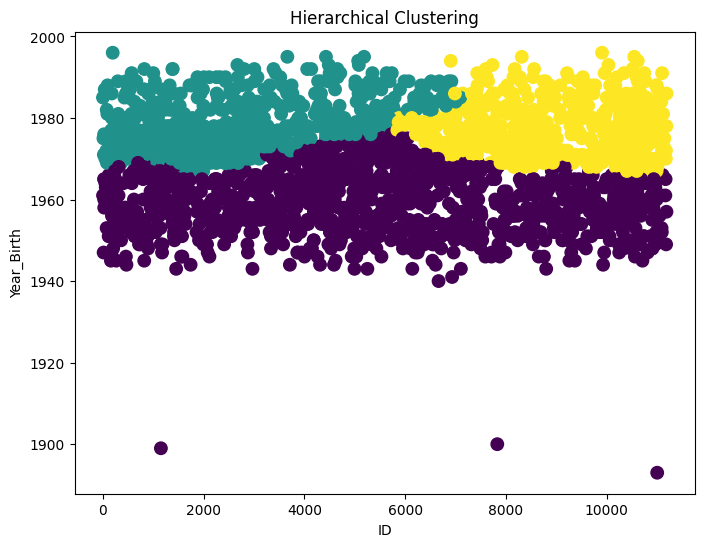

In [26]:
# ==========================================
# Step 17: Cluster Visualization
# ==========================================

plt.figure(figsize=(8,6))

plt.scatter(
    data["ID"],
    data["Year_Birth"],
    c=data["Cluster"],
    cmap="viridis",
    s=80
)

plt.title("Hierarchical Clustering")

plt.xlabel("ID")

plt.ylabel("Year_Birth")

plt.show()

In [28]:
data.groupby("Cluster").mean(numeric_only=True)

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain
Cluster,,,,,,,,,,,,,,,,,,,,,
0,5497.007048,1959.478414,55693.550401,0.333040,0.681938,49.798238,348.834361,27.555066,173.054626,38.760352,...,2.962996,6.166520,5.071366,0.058150,0.088106,0.072247,0.065198,0.013216,0.148018,0.009692
1,2809.000000,1979.078231,48603.786942,0.564626,0.295918,49.161565,265.889456,25.465986,170.450680,39.369048,...,2.448980,5.431973,5.556122,0.100340,0.059524,0.083333,0.071429,0.013605,0.161565,0.008503
2,8966.427466,1977.599613,48849.970760,0.551257,0.359768,47.537718,248.638298,24.502901,149.566731,32.717602,...,2.243714,5.371373,5.582205,0.073501,0.061896,0.061896,0.054159,0.013540,0.137331,0.009671
